# Pointer Networks (Ptr-Net) — Implementation

For theory and mathematical foundations see **`notebook_theory.ipynb`**.

**Files:**
```
model.py   — Encoder, Attention, PointerNetwork
data.py    — data helpers and dataset loader
train.py   — training loop (run from terminal)
```


In [5]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                     MODEL CONFIGURATION                             ║
# ║  Choose the size to use throughout this notebook.                   ║
# ║  Run the matching train.py command first if you haven't already.    ║
# ║                                                                      ║
# ║  Commands:                                                           ║
# ║    python train.py --size small  --steps 1000  --out model/ptr_net_small.pt  ║
# ║    python train.py --size medium --steps 3000  --out model/ptr_net_medium.pt ║
# ║    python train.py --size large  --steps 5000  --out model/ptr_net_large.pt  ║
# ╚══════════════════════════════════════════════════════════════════════╝

#   'small'  — embed=64,  hidden=128, layers=1  (~230K params)
#   'medium' — embed=128, hidden=256, layers=1  (~920K params)  ← paper default
#   'large'  — embed=256, hidden=512, layers=2  (~3.7M params)
SIZE       = "small"
MODEL_PATH = f"model/ptr_net_{SIZE}.pt"

print(f"Using model: {SIZE}  →  {MODEL_PATH}")


Using model: small  →  model/ptr_net_small.pt


In [6]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import permutations

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from data import random_instance, tour_length, optimal_tour, load_cities
from model import PointerNetwork, MODEL_SIZES
from train import train

print('Modules imported successfully.')
print('\nParameter counts per preset:')
for size, (e, h, l) in MODEL_SIZES.items():
    n_params = sum(p.numel() for p in PointerNetwork(e, h, l).parameters())
    print(f'  {size:<8} embed={e:>3}, hidden={h:>3}, layers={l}  →  {n_params:>10,} parameters')


Modules imported successfully.

Parameter counts per preset:
  small    embed= 64, hidden=128, layers=1  →     232,000 parameters
  medium   embed=128, hidden=256, layers=1  →     922,752 parameters
  large    embed=256, hidden=512, layers=2  →   5,781,760 parameters


## 7. Implementation

Source files:

| File | Role |
|------|------|
| `model.py` | `Encoder`, `Attention`, `PointerNetwork` classes |
| `data.py` | `random_instance`, `optimal_tour`, `tour_length`, `load_cities` |
| `train.py` | Supervised training loop (CLI + importable `train()`) |


## 8. Demonstration

> The model is trained externally via `train.py`. Run one of the commands
> in the config cell above, then execute the cells below.


Loaded small model (232,000 params) — 500 training steps, best loss 0.4628
Optimal tour length  : 2.1586
Ptr-Net greedy tour  : 2.9798  (gap = 38.0 %)


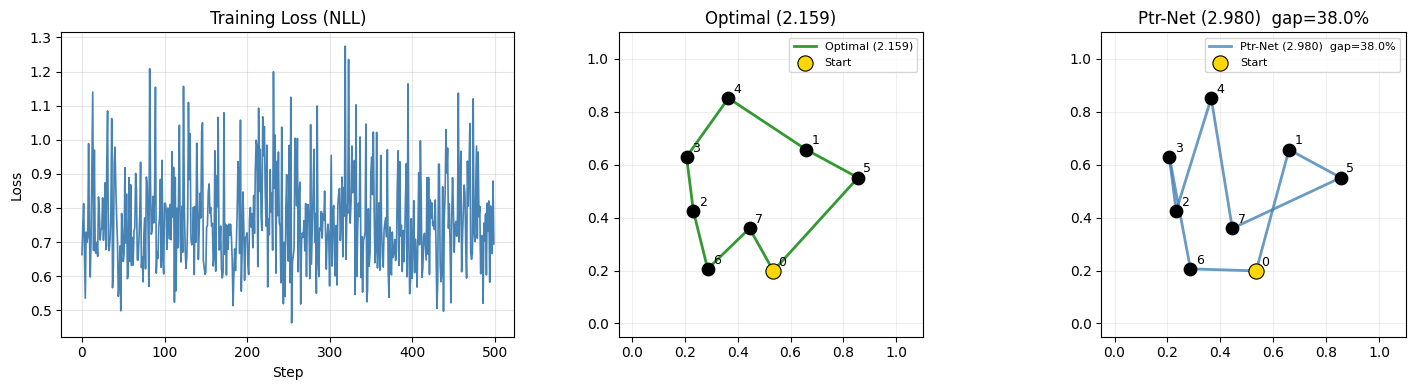


Ptr-Net tour : 0 → 1 → 5 → 7 → 4 → 2 → 3 → 6 → 0
Optimal      : 0 → 5 → 1 → 4 → 3 → 2 → 6 → 7 → 0


In [10]:
# ── Load trained model (SIZE and MODEL_PATH from config cell) ─────────────────
embed, hidden, n_layers = MODEL_SIZES[SIZE]
model_demo = PointerNetwork(embed_dim=embed, hidden_dim=hidden, n_layers=n_layers)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"{MODEL_PATH} not found — run train.py first.")

model_demo.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
model_demo.eval()
losses = np.load('model/losses.npy').tolist()
print(f'Loaded {SIZE} model ({sum(p.numel() for p in model_demo.parameters()):,} params)'
      f' — {len(losses)} training steps, best loss {min(losses):.4f}')

# ── Inference on one held-out instance ───────────────────────────────────────
N_DEMO = 8
torch.manual_seed(7)
coords    = random_instance(N_DEMO)
opt_tour  = optimal_tour(coords)
opt_len   = tour_length(coords, opt_tour)

with torch.no_grad():
    _, ptr_tour = model_demo(coords)

ptr_len = tour_length(coords, ptr_tour)
gap     = (ptr_len - opt_len) / opt_len * 100
print(f'Optimal tour length  : {opt_len:.4f}')
print(f'Ptr-Net greedy tour  : {ptr_len:.4f}  (gap = {gap:.1f} %)')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) Loss curve
axes[0].plot(losses, color='steelblue', lw=1.2)
axes[0].set_title('Training Loss (NLL)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# 2 & 3) Tour comparison
xy = coords.numpy()

def draw_tour(ax, xy, tour, color, lw, label):
    tc = tour + [tour[0]]
    for k in range(len(tc) - 1):
        a, b = tc[k], tc[k + 1]
        ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                color=color, lw=lw, alpha=0.8, label=label if k == 0 else None)

for ax, tour, color, title in [
    (axes[1], opt_tour,  'green',     f'Optimal ({opt_len:.3f})'),
    (axes[2], ptr_tour,  'steelblue', f'Ptr-Net ({ptr_len:.3f})  gap={gap:.1f}%'),
]:
    draw_tour(ax, xy, tour, color, 2.0, title)
    ax.scatter(xy[:, 0], xy[:, 1], s=80, zorder=5, color='black')
    ax.scatter(xy[0, 0], xy[0, 1], s=120, zorder=6, color='gold',
               edgecolors='black', linewidths=0.8, label='Start')
    for i, (xi, yi) in enumerate(xy):
        ax.annotate(str(i), (xi + 0.02, yi + 0.02), fontsize=9)
    ax.set_title(title)
    ax.set_xlim(-0.05, 1.10)
    ax.set_ylim(-0.05, 1.10)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
print(f'\nPtr-Net tour : {" → ".join(map(str, ptr_tour + [ptr_tour[0]]))}')
print(f'Optimal      : {" → ".join(map(str, opt_tour + [opt_tour[0]]))}')


## 9. Benchmark

> Inference time and solution quality vs instance size.
> The selected model is used for all sizes — quality degrades beyond training size (n=8).


     n   time (ms)     Ptr-Net          NN     gap %
----------------------------------------------------
    10       33.98      5.3718      4.4134    +21.72%
    50      105.85     19.0787      7.5857   +151.51%
   100      120.14     39.1270      9.5817   +308.35%
   200      747.52     68.8658     13.9632   +393.20%


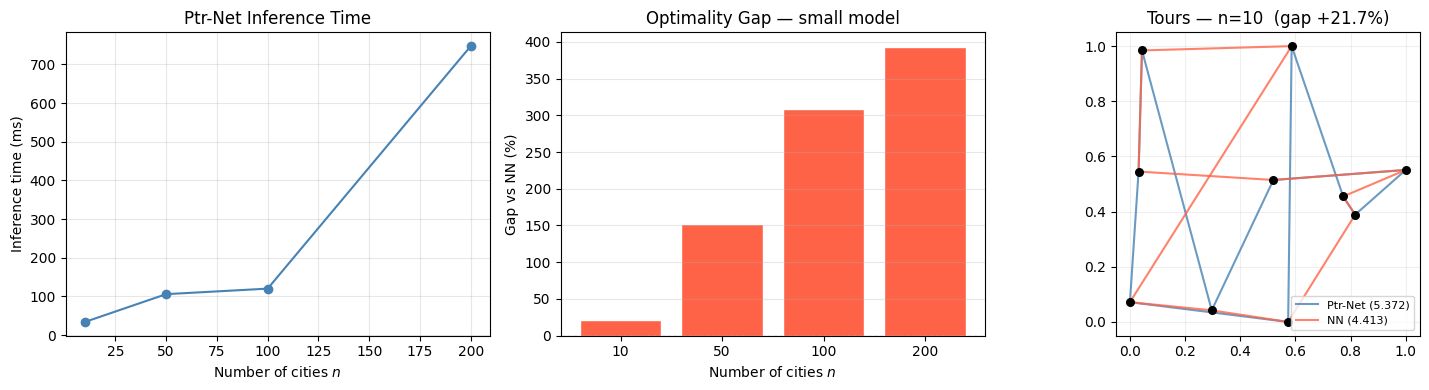

In [9]:
# ── Benchmark: inference time + gap vs nearest-neighbour ──────────────────────
embed, hidden, n_layers = MODEL_SIZES[SIZE]
model_bench = PointerNetwork(embed_dim=embed, hidden_dim=hidden,
                              n_layers=n_layers).eval()
if os.path.exists(MODEL_PATH):
    model_bench.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))

def nearest_neighbour_tour(coords):
    n = coords.shape[0]
    visited = torch.zeros(n, dtype=torch.bool)
    tour = [0]
    visited[0] = True
    for _ in range(n - 1):
        dists = torch.cdist(coords[tour[-1]].unsqueeze(0), coords).squeeze(0)
        dists[visited] = float('inf')
        tour.append(dists.argmin().item())
        visited[tour[-1]] = True
    return tour

BENCH_SIZES = [10, 50, 100, 200]
N_REPS      = 10
results     = []

print(f"{'n':>6}  {'time (ms)':>10}  {'Ptr-Net':>10}  {'NN':>10}  {'gap %':>8}")
print('-' * 52)

with torch.no_grad():
    for n in BENCH_SIZES:
        coords = load_cities(n, source='tsp')
        times  = []
        for _ in range(N_REPS):
            t0 = time.perf_counter()
            _, ptr_tour = model_bench(coords)
            times.append(time.perf_counter() - t0)
        ptr_len  = tour_length(coords, ptr_tour)
        nn_len   = tour_length(coords, nearest_neighbour_tour(coords))
        gap      = (ptr_len - nn_len) / nn_len * 100
        mean_ms  = np.mean(times) * 1e3
        results.append({'n': n, 'ms': mean_ms, 'ptr': ptr_len,
                         'nn': nn_len, 'gap': gap})
        print(f'{n:>6}  {mean_ms:>10.2f}  {ptr_len:>10.4f}  {nn_len:>10.4f}  {gap:>+8.2f}%')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ns   = [r['n']   for r in results]
ms   = [r['ms']  for r in results]
gaps = [r['gap'] for r in results]

axes[0].plot(ns, ms, 'o-', color='steelblue')
axes[0].set_xlabel('Number of cities $n$')
axes[0].set_ylabel('Inference time (ms)')
axes[0].set_title('Ptr-Net Inference Time')
axes[0].grid(True, alpha=0.3)

axes[1].bar([str(n) for n in ns], gaps,
            color=['steelblue' if g <= 0 else 'tomato' for g in gaps],
            edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xlabel('Number of cities $n$')
axes[1].set_ylabel('Gap vs NN (%)')
axes[1].set_title(f'Optimality Gap — {SIZE} model')
axes[1].grid(True, axis='y', alpha=0.3)

# Tour plot for smallest size
r0     = results[0]
coords = load_cities(r0['n'], source='tsp')
with torch.no_grad():
    _, ptr_tour = model_bench(coords)
nn_tour = nearest_neighbour_tour(coords)
xy      = coords.numpy()

def _draw(ax, xy, tour, color, label):
    tc = tour + [tour[0]]
    for k in range(len(tc)-1):
        a, b = tc[k], tc[k+1]
        ax.plot([xy[a,0],xy[b,0]], [xy[a,1],xy[b,1]],
                color=color, lw=1.5, alpha=0.8, label=label if k==0 else None)

_draw(axes[2], xy, ptr_tour, 'steelblue', f"Ptr-Net ({r0['ptr']:.3f})")
_draw(axes[2], xy, nn_tour,  'tomato',    f"NN ({r0['nn']:.3f})")
axes[2].scatter(xy[:,0], xy[:,1], s=30, zorder=5, color='black')
axes[2].set_title(f"Tours — n={r0['n']}  (gap {r0['gap']:+.1f}%)")
axes[2].legend(fontsize=8)
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
